# Makine Öğrenmesi

## Veri Ön İşleme Pratiği

Adımlar:
  1. kütüphaneleri içeri aktar
  2. csv dosyasını yükle ve veriyi incele
  3. eksik verilerin gösterilmesi drop ile çıkartma ve median ile doldurma
  4. label encoding ve one hot encoding
  5. sayısal sütunlara standardization ve normalization
  6. train test split ile verinin 2 ye ayrılması

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
df = pd.read_csv("musteri_verisi_ml_pratik.csv")
df.head()

,yas,maas,sehir,egitim,deneyim_yili,satin_aldi
0,25.0,32000.0,Ankara,Lisans,1.0,Evet
1,31.0,41000.0,Istanbul,Yuksek Lisans,4.0,Hayir
2,28.0,NaN,Izmir,Lisans,2.0,Beklemede
3,45.0,67000.0,Ankara,Doktora,15.0,Hayir
4,NaN,52000.0,Bursa,Lisans,7.0,Evet


In [3]:
df.isnull().sum()

yas             1
maas            1
sehir           0
egitim          1
deneyim_yili    1
satin_aldi      0
dtype: int64

In [4]:
df_dropna = df.dropna()
df_dropna

,yas,maas,sehir,egitim,deneyim_yili,satin_aldi
0,25.0,32000.0,Ankara,Lisans,1.0,Evet
1,31.0,41000.0,Istanbul,Yuksek Lisans,4.0,Hayir
3,45.0,67000.0,Ankara,Doktora,15.0,Hayir
5,36.0,48000.0,Istanbul,On Lisans,6.0,Beklemede
7,41.0,61000.0,Ankara,Yuksek Lisans,11.0,Hayir
8,33.0,45000.0,Bursa,Lisans,5.0,Beklemede
10,38.0,56000.0,Izmir,Yuksek Lisans,9.0,Evet
11,30.0,43000.0,Ankara,Lisans,3.0,Beklemede


In [5]:
df_filled = df.copy()
sayisal_sutunlar = ["yas", "maas", "deneyim_yili"]

for sutun in sayisal_sutunlar:
    df_filled[sutun] = df_filled[sutun].fillna(df_filled[sutun].median())

In [6]:
df_filled

,yas,maas,sehir,egitim,deneyim_yili,satin_aldi
0,25.0,32000.0,Ankara,Lisans,1.0,Evet
1,31.0,41000.0,Istanbul,Yuksek Lisans,4.0,Hayir
2,28.0,45000.0,Izmir,Lisans,2.0,Beklemede
3,45.0,67000.0,Ankara,Doktora,15.0,Hayir
4,31.0,52000.0,Bursa,Lisans,7.0,Evet
5,36.0,48000.0,Istanbul,On Lisans,6.0,Beklemede
6,29.0,39000.0,Izmir,Lisans,5.0,Evet
7,41.0,61000.0,Ankara,Yuksek Lisans,11.0,Hayir
8,33.0,45000.0,Bursa,Lisans,5.0,Beklemede
9,27.0,35000.0,Istanbul,NaN,2.0,Hayir


In [7]:
df_filled["egitim"] = df_filled["egitim"].fillna(df_filled["egitim"].mode()[0])
df_filled

,yas,maas,sehir,egitim,deneyim_yili,satin_aldi
0,25.0,32000.0,Ankara,Lisans,1.0,Evet
1,31.0,41000.0,Istanbul,Yuksek Lisans,4.0,Hayir
2,28.0,45000.0,Izmir,Lisans,2.0,Beklemede
3,45.0,67000.0,Ankara,Doktora,15.0,Hayir
4,31.0,52000.0,Bursa,Lisans,7.0,Evet
5,36.0,48000.0,Istanbul,On Lisans,6.0,Beklemede
6,29.0,39000.0,Izmir,Lisans,5.0,Evet
7,41.0,61000.0,Ankara,Yuksek Lisans,11.0,Hayir
8,33.0,45000.0,Bursa,Lisans,5.0,Beklemede
9,27.0,35000.0,Istanbul,Lisans,2.0,Hayir


In [8]:
# # 4. Label Encoding ve One-Hot Encoding uygulayacağız.
label_df = df_filled.copy()
label_encoder = LabelEncoder()
label_df["satin_aldi_label"] = label_encoder.fit_transform(label_df["satin_aldi"])
label_df
#

,yas,maas,sehir,egitim,deneyim_yili,satin_aldi,satin_aldi_label
0,25.0,32000.0,Ankara,Lisans,1.0,Evet,1
1,31.0,41000.0,Istanbul,Yuksek Lisans,4.0,Hayir,2
2,28.0,45000.0,Izmir,Lisans,2.0,Beklemede,0
3,45.0,67000.0,Ankara,Doktora,15.0,Hayir,2
4,31.0,52000.0,Bursa,Lisans,7.0,Evet,1
5,36.0,48000.0,Istanbul,On Lisans,6.0,Beklemede,0
6,29.0,39000.0,Izmir,Lisans,5.0,Evet,1
7,41.0,61000.0,Ankara,Yuksek Lisans,11.0,Hayir,2
8,33.0,45000.0,Bursa,Lisans,5.0,Beklemede,0
9,27.0,35000.0,Istanbul,Lisans,2.0,Hayir,2


In [9]:
onehot_target_df = pd.get_dummies(df["satin_aldi"], prefix = "satin_aldi")
onehot_target_df

,satin_aldi_Beklemede,satin_aldi_Evet,satin_aldi_Hayir
0,False,True,False
1,False,False,True
2,True,False,False
3,False,False,True
4,False,True,False
5,True,False,False
6,False,True,False
7,False,False,True
8,True,False,False
9,False,False,True


In [10]:
onehot_df = pd.get_dummies(df_filled, columns = ["egitim"], drop_first=True)
onehot_df["satin_aldi"] = label_encoder.fit_transform(onehot_df["satin_aldi"])
onehot_df

,yas,maas,sehir,deneyim_yili,satin_aldi,egitim_Lisans,egitim_On Lisans,egitim_Yuksek Lisans
0,25.0,32000.0,Ankara,1.0,1,True,False,False
1,31.0,41000.0,Istanbul,4.0,2,False,False,True
2,28.0,45000.0,Izmir,2.0,0,True,False,False
3,45.0,67000.0,Ankara,15.0,2,False,False,False
4,31.0,52000.0,Bursa,7.0,1,True,False,False
5,36.0,48000.0,Istanbul,6.0,0,False,True,False
6,29.0,39000.0,Izmir,5.0,1,True,False,False
7,41.0,61000.0,Ankara,11.0,2,False,False,True
8,33.0,45000.0,Bursa,5.0,0,True,False,False
9,27.0,35000.0,Istanbul,2.0,2,True,False,False


In [11]:
X = onehot_df.drop("satin_aldi", axis = 1) # features
y = onehot_df["satin_aldi"] # target


In [12]:
# 5. Yalnızca sayısal sütunlarda Standardization ve Normalization yapacağız.
sayisal_ozellikler = ["yas", "maas", "deneyim_yili"]

In [13]:
X_standard = X.copy()
standard_scaler = StandardScaler()
X_standard[sayisal_ozellikler] = standard_scaler.fit_transform(X_standard[sayisal_ozellikler])


In [14]:
X_standard

,yas,maas,sehir,deneyim_yili,egitim_Lisans,egitim_On Lisans,egitim_Yuksek Lisans
0,-1.357339,-1.502506,Ankara,-1.222204,True,False,False
1,-0.317675,-0.601003,Istanbul,-0.463595,False,False,True
2,-0.837507,-0.200334,Izmir,-0.969334,True,False,False
3,2.108207,2.003342,Ankara,2.317974,False,False,False
4,-0.317675,0.500835,Bursa,0.295015,True,False,False
5,0.548711,0.100167,Istanbul,0.042145,False,True,False
6,-0.664230,-0.801337,Izmir,-0.210725,True,False,False
7,1.415098,1.402339,Ankara,1.306494,False,False,True
8,0.028880,-0.200334,Bursa,-0.210725,True,False,False
9,-1.010784,-1.202005,Istanbul,-0.969334,True,False,False


In [15]:
X_normalized = X.copy()
minmax_scaler = MinMaxScaler()
X_normalized[sayisal_ozellikler] = minmax_scaler.fit_transform(X_normalized[sayisal_ozellikler])
X_normalized

,yas,maas,sehir,deneyim_yili,egitim_Lisans,egitim_On Lisans,egitim_Yuksek Lisans
0,0.00,0.000000,Ankara,0.000000,True,False,False
1,0.30,0.257143,Istanbul,0.214286,False,False,True
2,0.15,0.371429,Izmir,0.071429,True,False,False
3,1.00,1.000000,Ankara,1.000000,False,False,False
4,0.30,0.571429,Bursa,0.428571,True,False,False
5,0.55,0.457143,Istanbul,0.357143,False,True,False
6,0.20,0.200000,Izmir,0.285714,True,False,False
7,0.80,0.828571,Ankara,0.714286,False,False,True
8,0.40,0.371429,Bursa,0.285714,True,False,False
9,0.10,0.085714,Istanbul,0.071429,True,False,False


In [16]:
# 6. Train-test split ile veriyi eğitim ve test olarak ayıracağız.
X_train, X_test, y_train, y_test = train_test_split(X_standard, y, test_size = 0.2, random_state = 42)
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (9, 7)
X_test (3, 7)
y_train (9,)
y_test (3,)


## Öznitelik Mühendisliği

Adımlar:
1. mevcut sütunlardan yeni özellikler üret (feature extraction)
2. hedef değişken ile öznitelik arasındaki korelasyonları incele
3. mutlak korelasyon değeri yüksek olan öznitelikleri seç (feature selection)

In [17]:
import pandas as pd

In [18]:
df = pd.read_csv("oznitelik_muhendisligi_pratik.csv")
df.head()

,yas,deneyim_yili,aylik_harcama,uyelik_suresi_ay,sehir,performans_puani
0,24,1,3200,6,Ankara,58
1,27,3,4100,12,Istanbul,64
2,31,5,5200,18,Izmir,71
3,35,8,6100,24,Ankara,79
4,29,4,4700,15,Bursa,68


In [19]:
# 1. mevcut sütunlardan yeni özellikler üret (feature extraction)
df["deneyim_orani"] = df["deneyim_yili"] / df["yas"]
df["yillik_harcama_tahmini"] = df["aylik_harcama"] * 12
df

,yas,deneyim_yili,aylik_harcama,uyelik_suresi_ay,sehir,performans_puani,deneyim_orani,yillik_harcama_tahmini
0,24,1,3200,6,Ankara,58,0.041667,38400
1,27,3,4100,12,Istanbul,64,0.111111,49200
2,31,5,5200,18,Izmir,71,0.161290,62400
3,35,8,6100,24,Ankara,79,0.228571,73200
4,29,4,4700,15,Bursa,68,0.137931,56400
5,42,14,7600,40,Istanbul,88,0.333333,91200
6,38,11,6900,32,Izmir,84,0.289474,82800
7,26,2,3600,8,Ankara,61,0.076923,43200
8,33,7,5900,20,Bursa,75,0.212121,70800
9,45,16,8100,46,Istanbul,91,0.355556,97200


In [20]:
# 2. hedef değişken ile öznitelik arasındaki korelasyonları incele
sayisal_df = df.drop("sehir", axis = 1)
korelasyonlar = sayisal_df.corr()["performans_puani"].sort_values(ascending = False)
korelasyonlar

performans_puani          1.000000
yillik_harcama_tahmini    0.998033
aylik_harcama             0.998033
deneyim_orani             0.997640
yas                       0.991814
deneyim_yili              0.985984
uyelik_suresi_ay          0.982116
Name: performans_puani, dtype: float64

In [21]:
# 3. mutlak korelasyon değeri yüksek olan öznitelikleri seç (feature selection)
secilen_oznitelikler = korelasyonlar[abs(korelasyonlar) > 0.995].index.tolist()
secilen_oznitelikler.remove("performans_puani")
secilen_oznitelikler

['yillik_harcama_tahmini', 'aylik_harcama', 'deneyim_orani']

In [22]:
"""
Çapraz Doğrulama Yöntemleri Pratiği

Amaç:
    1. K-Fold, Stratified K-Fold ve Leave-One-Out yöntemlerini aynı veri seti üzerinde uygulamak.
    2. Bu üç yöntemin model değerlendirme mantığını sade ve karşılaştırmalı biçimde göstermek.

Adımlar:
    1. Gerekli kütüphaneleri içe aktaracağız.
    2. Örnek veri setini yükleyeceğiz.
    3. Basit bir sınıflandırma modeli tanımlayacağız.
    4. K-Fold ile çapraz doğrulama yapacağız.
    5. Stratified K-Fold ile çapraz doğrulama yapacağız.
    6. Leave-One-Out ile çapraz doğrulama yapacağız.
    7. Sonuçları birlikte yazdıracağız.

Kurulumlar:
    pip install scikit-learn numpy
"""

# 1. Gerekli kütüphaneleri içe aktaracağız.
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut, cross_val_score

# 2. Örnek veri setini yükleyeceğiz.
X, y = load_iris(return_X_y=True)

# 3. Basit bir sınıflandırma modeli tanımlayacağız.
model = LogisticRegression(max_iter=200)

# 4. K-Fold ile çapraz doğrulama yapacağız.
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

# 5. Stratified K-Fold ile çapraz doğrulama yapacağız.
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stratified_scores = cross_val_score(model, X, y, cv=stratified_kfold, scoring="accuracy")

# 6. Leave-One-Out ile çapraz doğrulama yapacağız.
loo = LeaveOneOut()
loo_scores = cross_val_score(model, X, y, cv=loo, scoring="accuracy")

# 7. Sonuçları birlikte yazdıracağız.
print("\nK-Fold Skorları:")
print(kfold_scores)
print("Ortalama Accuracy:", np.mean(kfold_scores).round(4))

print("\nStratified K-Fold Skorları:")
print(stratified_scores)
print("Ortalama Accuracy:", np.mean(stratified_scores).round(4))

print("\nLeave-One-Out Sonucu:")
print("Toplam Test Sayısı:", len(loo_scores))
print("Ortalama Accuracy:", np.mean(loo_scores).round(4))



K-Fold Skorları:
[1.         1.         0.93333333 0.96666667 0.96666667]
Ortalama Accuracy: 0.9733

Stratified K-Fold Skorları:
[1.         0.96666667 0.93333333 1.         0.93333333]
Ortalama Accuracy: 0.9667

Leave-One-Out Sonucu:
Toplam Test Sayısı: 150
Ortalama Accuracy: 0.9667


## Karar Ağaçları

Amaç:
  1. iris veri setini kullanarak karar ağaçları ile sınıflandırma problemi çözme

Veri seti:
  1. 3 farklı çiçek sınıfı (etiketi):
    - setosa, versicolor, virginica
  2. Her örnek için 4 öznitelik bulunmaktadır.
    - sepal length
    - sepal width
    - petal length
    - petal width
  3. 150 tane örnek veri içermektedir.

Adımlar:
  1. veri setini yükle
  2. Feature (X) ve target (y) değişkenleri ayırma
  3. Eğitim ve test veri setlerinin oluşturulması
  4. karar ağacı modelinin oluşturulması ve eğitimi
  5. test verisi üzerinden tahmin yapılması
  6. model başarımının accuracy ile ölçülmesi
  7. Confusion matris oluşturulması ve görselleştirilmesi
  8. karar ağacının görselleştirilmesi
  9. Öznitelik önemlerinin (feauture importance) incelenmesi

kurulumlar:
pip install scikit-learn pandas matplotlib seaborn


In [23]:
# gerekli kütüphanelerini içeriye aktarılması
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

In [24]:
# 1. veri setini yükle
iris = load_iris()

df = pd.DataFrame(
    data = iris.data,
    columns = iris.feature_names
)
df["target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [25]:
# 2. feature ve target ayrımı
X = iris.data
y = iris.target

In [26]:
# 3. train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [27]:
# 4. karar ağacı modeli oluşturma
tree_clf = DecisionTreeClassifier(criterion = "gini", max_depth = 3, random_state = 42)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [28]:
# 5. test
y_pred = tree_clf.predict(X_test)

In [29]:
accuracy = accuracy_score(y_pred, y_test)
accuracy

1.0

In [30]:
# 7. confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]], dtype=int64)

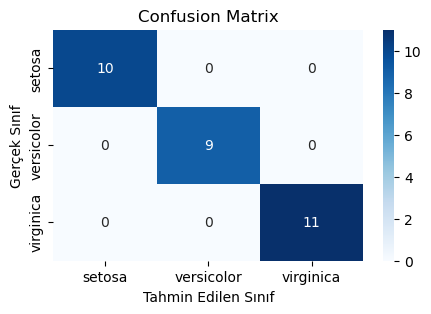

In [31]:
plt.figure(figsize=(5, 3))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="g",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Confusion Matrix")
plt.show()

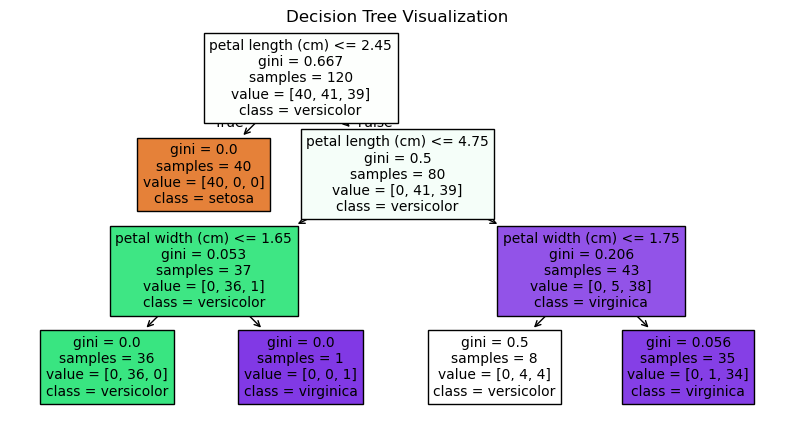

In [32]:
# 8. karar ağacının görselleştirilmesi
plt.figure(figsize=(10, 5))
plot_tree(
    tree_clf,
    filled=True,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names)
)
plt.title("Decision Tree Visualization")
plt.show()

In [33]:
# 9. feature importance
feature_importances = tree_clf.feature_importances_
feature_names = iris.feature_names

# Önem derecelerini büyükten küçüğe sıralayalım
feature_importances_sorted = sorted(
    zip(feature_importances, feature_names),
    reverse=True
)

print("\nÖzellik Önem Dereceleri:")
for importance, feature_name in feature_importances_sorted:
    print(f"{feature_name}: {importance:.4f}")


Özellik Önem Dereceleri:
petal length (cm): 0.9346
petal width (cm): 0.0654
sepal width (cm): 0.0000
sepal length (cm): 0.0000


## Kümeleme: K-Means Clustering

Amaç:
  - sentetik veri oluşturarak kmeans algoritması geliştirme

Veri seti:
  1. 300 samples, 2 boyutlu, 4 küme

Adımlar:
  1. Veri seti oluşturma
  2. Veri Noktalarının görselleştirilmesi
  3. K-Means modelinin tanımlanması ve eğitimi
  4. her veri noktasının ait olduğu kümenin belirlenmesi
  5. küme merkerzi görselleştir

Kurulumlar:
pip install scikit-learn matplotlib

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [35]:
# 1. veri seti oluşturma
X, _ = make_blobs(n_samples = 300, centers = 4, cluster_std = 0.6, random_state = 42)

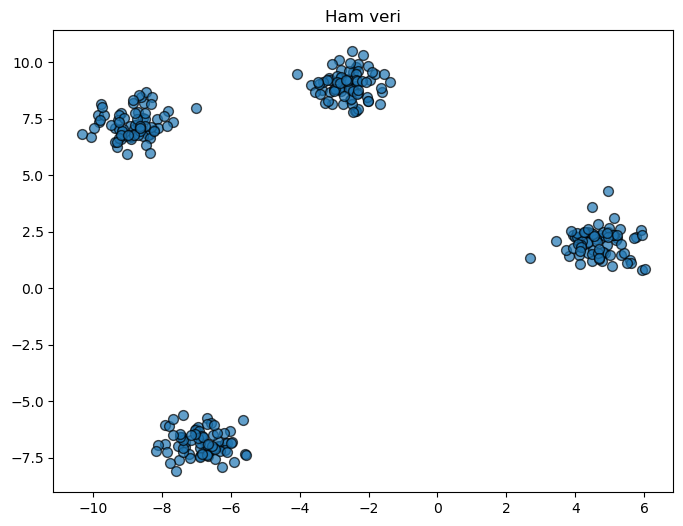

In [36]:
# 2. veri noktalarının görselleştirilmesi
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], s = 50, alpha = 0.7, edgecolors="k")
plt.title("Ham veri")
plt.show()

In [37]:
# 3. kmeans modelinin tanımlanması ve eğitimi
kmeans = KMeans(n_clusters = 4)
kmeans.fit(X)

c:\Users\misafir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=4)

In [38]:
# 4-5 küme merkezi görselleştir
plt.figure()
labels = kmeans.labels_

<Figure size 640x480 with 0 Axes>

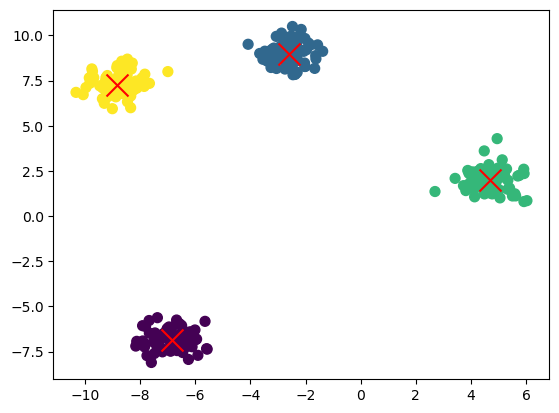

In [39]:
plt.scatter(X[:,0], X[:,1], c = labels, cmap = "viridis", s = 50)
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c = "red", s = 250, marker = "x")

## Hiyerarşik Kümeleme

Amaç:
  1. sentetik bir veri oluştur ve hiyerarşik kümeleme uygula

Adımlar:
  1. veri seti oluşturma
  2. ham veri görselleştirme
  3. hiyerarşik kümeleme modeli kurma
  4. veri noktalarının ait olduğu kümeleri belirle
  5. sonuçları görselleştir
  6. dendrogram çizerek birleşme yapısını göster
  

In [40]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

In [41]:
# veri setini oluşturma
X, _ = make_blobs(n_samples = 300, centers = 4, cluster_std = 0.7, random_state = 42)

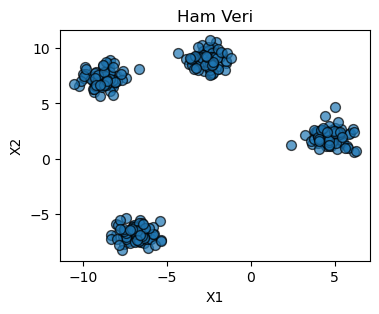

In [42]:
# 2. Ham veriyi görselleştireceğiz
plt.figure(figsize=(4, 3))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.7, edgecolors="k")
plt.title("Ham Veri")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


In [43]:
# 3. hiyerarşik kümeleme modeli
model = AgglomerativeClustering(n_clusters = 4)


In [44]:
# 4. veri noktalarının ait olduğu kümeleri belirle
labels = model.fit_predict(X)

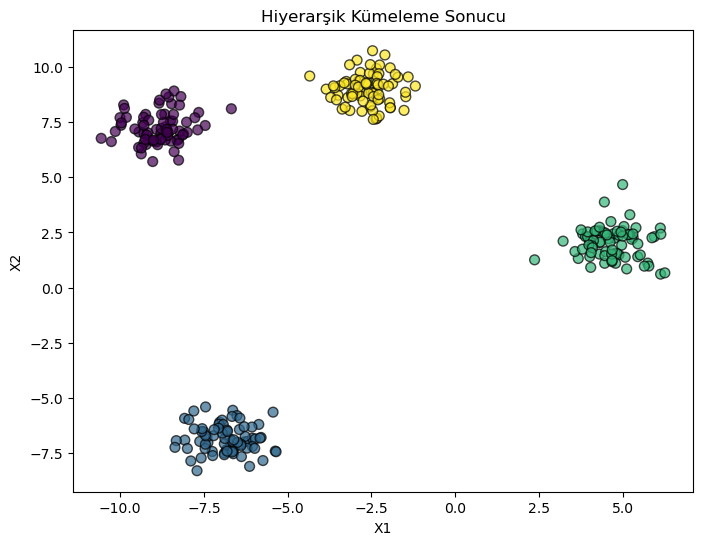

In [45]:
# 5. Sonuçları küme renkleri ile görselleştireceğiz
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=50, alpha=0.7, edgecolors="k")
plt.title("Hiyerarşik Kümeleme Sonucu")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

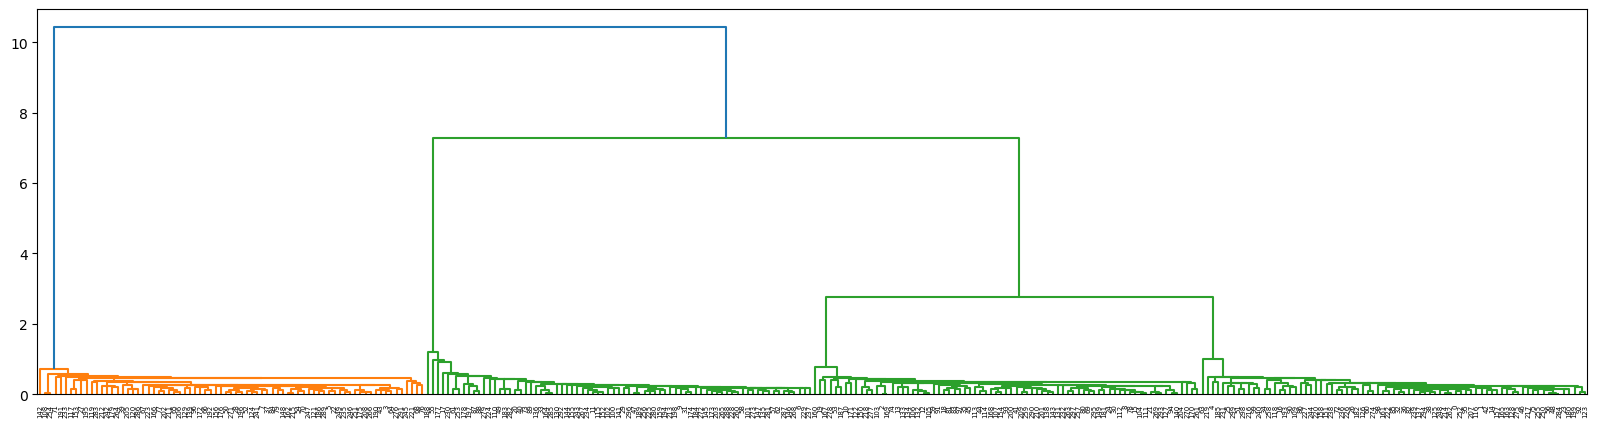

In [46]:
# 6. dendrogram
baglanti_matrisi = linkage(X)

plt.figure(figsize = (20,5))
dendrogram(baglanti_matrisi)
plt.show()

# Boyut indirgeme: PCA

Amaç:
  1. iris veri seti üzerinden boyut indirgeme ve görselleştirme
  2. 4 bileşenden 2 bileşene indirgeme

Adımlar:
  1. iris veri setinin yüklenmesi
  2. özellik ve target değişkenlerin tanımlanması
  3. pca modelinin 2 bileşen ile tanımlanması
  4. pca dönüşümünün uygulanması
  5. dönüştürülmüş verinin 2 boyutlu olarak görselleştirilmesi



In [47]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [48]:
iris = load_iris()
X = iris.data
y = iris.target

In [49]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

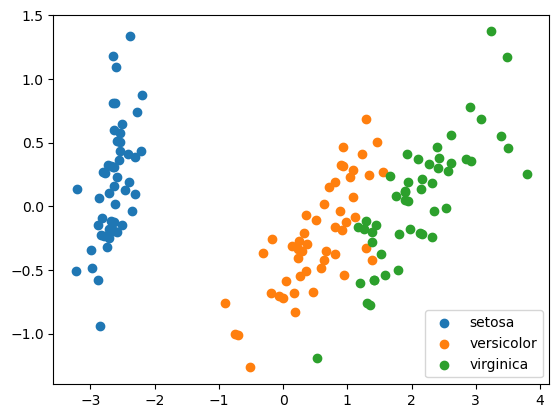

In [50]:
# pca dönüşümü sonrası veri görselleştirme
plt.figure()
for i in range(len(iris.target_names)):
  plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label = iris.target_names[i])
plt.legend()

## Çapraz Doğrulama (Cross Validation)

Amaç:
  1. Çapraz doğrulama yöntemlerini karşılaştırma

Adımlar:
  1. veri seti yükleme
  2. basit bir sınıflandırma modeli tanımlama
  3. basit bir sınıflandırma modeli tanımla
  4. kfold
  5. stratified kfold
  6. loo

In [51]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut, cross_val_score

In [52]:
# örnek veri seti yükleme
X, y = load_iris(return_X_y=True)

In [53]:
model = LogisticRegression(max_iter = 200)

In [54]:
# kfold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")
kfold_scores

array([1.        , 1.        , 0.93333333, 0.96666667, 0.96666667])

In [55]:
# stratified k fold
stratified_kfold = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)
stratified_kfold_scores = cross_val_score(model, X, y, cv=stratified_kfold, scoring="accuracy")
stratified_kfold_scores

array([1.        , 0.96666667, 0.93333333, 1.        , 0.93333333])

In [56]:
# stratified k fold
loo = LeaveOneOut()
loo_scores = cross_val_score(model, X, y, cv=loo, scoring="accuracy")
loo_scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

## Hiperparametre Tuning

Amaç:
  1. KNN, Decision Tree ve Logistic Regression modelleri için Grdi search ve random search uygulaması yapalım

Adımlar:
  1. örnek veri seti
  2. her model için hiperparametre uzayı belirleme
  3. grid search ile en iyi hiperparamtreleri bul
  4. random search ile en iyi hiperparamtreleri bul

In [57]:
# 1. Gerekli kütüphaneleri içe aktaracağız.
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [58]:
# 2. Örnek veri setini yükleyip eğitim ve test olarak ayıracağız.
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [59]:
# 3. Her model için hiperparametre arama uzayını tanımlayacağız.
models_and_params = {
    "KNN": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "grid_params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__metric": ["euclidean", "manhattan"]
        },
        "random_params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__metric": ["euclidean", "manhattan", "minkowski"]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeClassifier(random_state=42))
        ]),
        "grid_params": {
            "model__max_depth": [2, 3, 4, 5, None],
            "model__min_samples_split": [2, 4, 6],
            "model__criterion": ["gini", "entropy"]
        },
        "random_params": {
            "model__max_depth": [2, 3, 4, 5, None],
            "model__min_samples_split": [2, 4, 6],
            "model__criterion": ["gini", "entropy"]
        }
    },
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=500, random_state=42))
        ]),
        "grid_params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        },
        "random_params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        }
    }
}

In [60]:
results = []

# 4. Grid Search ile en iyi parametreleri bulacağız.
# 5. Random Search ile en iyi parametreleri bulacağız.
# 6. En iyi modelleri test verisi üzerinde değerlendireceğiz.
for model_name, item in models_and_params.items():
    grid_search = GridSearchCV(
        estimator=item["pipeline"],
        param_grid=item["grid_params"],
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    grid_test_score = accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))

    random_search = RandomizedSearchCV(
        estimator=item["pipeline"],
        param_distributions=item["random_params"],
        n_iter=4,
        cv=3,
        scoring="accuracy",
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)
    random_test_score = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))

    results.append({
        "Model": model_name,
        "Yöntem": "Grid Search",
        "CV En İyi Skor": round(grid_search.best_score_, 4),
        "Test Skoru": round(grid_test_score, 4),
        "En İyi Parametreler": str(grid_search.best_params_)
    })

    results.append({
        "Model": model_name,
        "Yöntem": "Random Search",
        "CV En İyi Skor": round(random_search.best_score_, 4),
        "Test Skoru": round(random_test_score, 4),
        "En İyi Parametreler": str(random_search.best_params_)
    })

# 7. Sonuçları özet tablo halinde yazdıracağız.
results_df = pd.DataFrame(results)
results_df

c:\Users\misafir\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
12 fits failed out of a total of 24.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\misafir\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\misafir\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\misafir\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estim

,Model,Yöntem,CV En İyi Skor,Test Skoru,En İyi Parametreler
0,KNN,Grid Search,0.9693,0.9737,"{'model__metric': 'manhattan', 'model__n_neigh..."
1,KNN,Random Search,0.9671,0.9561,"{'model__n_neighbors': 5, 'model__metric': 'mi..."
2,Decision Tree,Grid Search,0.9363,0.9386,"{'model__criterion': 'gini', 'model__max_depth..."
3,Decision Tree,Random Search,0.9296,0.9123,"{'model__min_samples_split': 2, 'model__max_de..."
4,Logistic Regression,Grid Search,0.9802,0.9737,"{'model__C': 0.1, 'model__penalty': 'l2'}"
5,Logistic Regression,Random Search,0.9802,0.9825,"{'model__penalty': 'l2', 'model__C': 1}"


EN:

Hyperparameter tuning results show that Logistic Regression achieved the highest test score with 98.25% using Random Search. KNN also produced strong performance, while Decision Tree remained comparatively lower. In general, parameter optimization improved model accuracy and demonstrated the importance of selecting suitable hyperparameters for each algorithm.

TR:

Hiperparametre optimizasyonu sonuçlarına göre en yüksek test başarısı %98.25 ile Random Search kullanılan Logistic Regression modelinde elde edilmiştir. KNN modeli de güçlü performans göstermiştir, Decision Tree modeli ise diğer modellere göre daha düşük kalmıştır. Genel olarak, parametre optimizasyonu model doğruluğunu artırmış ve her algoritma için uygun parametre seçiminin önemini göstermiştir.